## 載入＋前處理 ## 

In [1]:
import os
import pandas as pd

# 1. 設定基礎路徑 (確保與你的資料夾層級一致)
data_dir = "../data" 
files = ["diabetes.csv", "heart.csv", "stroke.csv"] # 或是 "storke.csv"

# 2. 用來存放結果的字典
all_datasets = {}

# 3. 執行迴圈：讀取、自動抓取最後一欄作為 Target
for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        # 讀取 CSV
        df = pd.read_csv(full_path)
        
        # --- 【核心邏輯】取得最後一欄並標記成 target ---
        target_name = df.columns[-1] 
        
        # 進行簡單的清理 (例如移除 ID，不分大小寫)
        id_cols = [c for c in df.columns if c.lower() == 'id']
        if id_cols:
            df = df.drop(columns=id_cols)
            target_name = df.columns[-1] 
            
        # --- 【診斷區】檢查標籤分佈 (回答你全 0 的疑惑) ---
        counts = df[target_name].value_counts()
        pos_cases = counts.get(1, 0) # 取得 1 (有病) 的數量，沒有則為 0
        
        # 存入字典
        dataset_key = filename.split('.')[0].capitalize()
        all_datasets[dataset_key] = (df, target_name)
        
        print(f"✅ {dataset_key:12} | Target: {target_name:15} | 案例數: {pos_cases}")
    else:
        print(f"❌ 找不到檔案: {filename}，請檢查路徑或拼字！")



✅ Diabetes     | Target: Outcome         | 案例數: 268
✅ Heart        | Target: target          | 案例數: 265
✅ Stroke       | Target: stroke          | 案例數: 249


🔍 --- 開始全自動深度清洗與熱圖驗證 ---

📂 資料集: 【Diabetes】
   📏 維度: 768x9 | 🎯 目標: Outcome
   ✨ 剩餘缺失值: 0


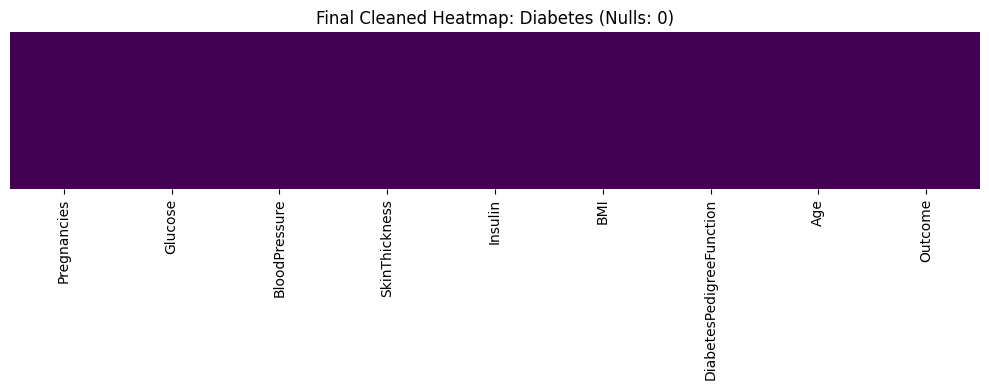

------------------------------------------------------------

📂 資料集: 【Heart】
   📏 維度: 920x14 | 🎯 目標: target
   ✨ 剩餘缺失值: 0


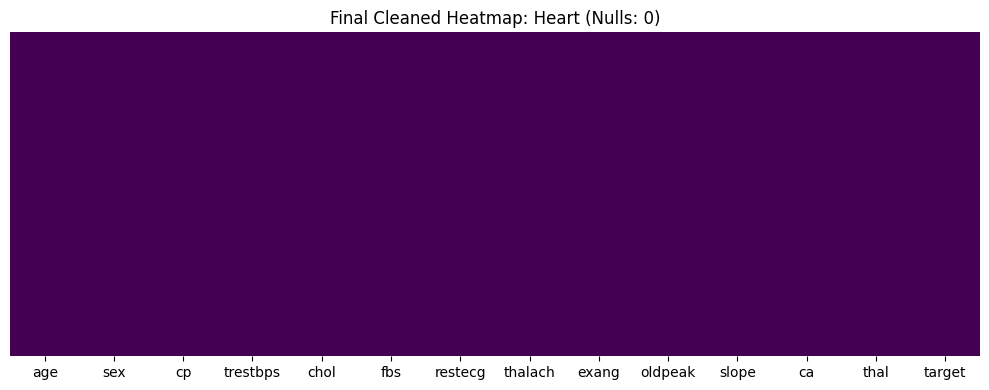

------------------------------------------------------------

📂 資料集: 【Stroke】
   📏 維度: 5110x11 | 🎯 目標: stroke
   ✨ 剩餘缺失值: 0


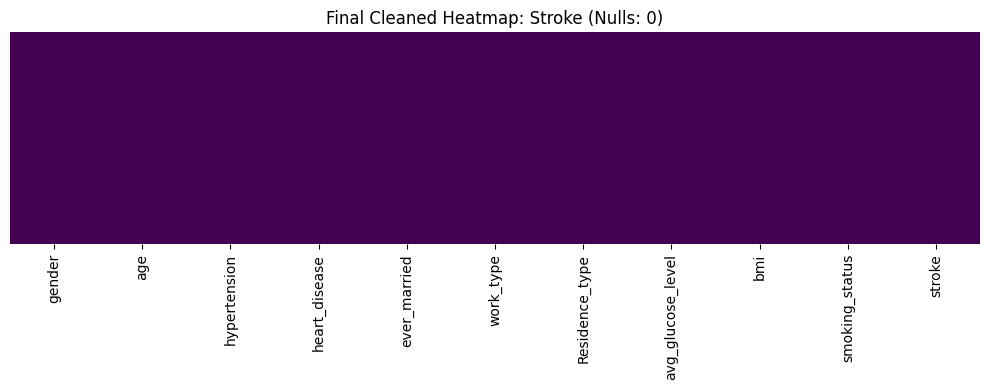

------------------------------------------------------------

🎉 所有資料集已清理完畢！現在妳可以安心去跑 Random Forest 的 AUC 了。


In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

print("🔍 --- 開始全自動深度清洗與熱圖驗證 ---")

for name, (df_item, target) in all_datasets.items():
    # --- 第一步：數據深度清理 (Data Scrubbing) ---
    
    # 1. 揭露隱性缺失 (包含妳新增的 'NAN' 字串)
    df_item.replace(['Unknown', 'N/A', '?', ' ', 'None', 'NAN'], np.nan, inplace=True)
    
    # 2. 自動修正型態 (核心：把被 ? 污染的欄位轉回數字)
    for col in df_item.columns:
        # 嘗試強制轉數字，這會讓無法轉換的殘留字串變成真正的 NaN
        converted = pd.to_numeric(df_item[col], errors='coerce')
        # 如果這一欄轉換後「至少包含一些數字」，我們就認定它是數值欄位
        if converted.notnull().sum() > 0:
            df_item[col] = converted

    # 3. 執行雙軌補值 (數字用 Median，文字用 Most Frequent)
    num_cols = df_item.select_dtypes(include=[np.number]).columns
    cat_cols = df_item.select_dtypes(include=['object']).columns
    
    if len(num_cols) > 0:
        df_item[num_cols] = SimpleImputer(strategy='median').fit_transform(df_item[num_cols])
    if len(cat_cols) > 0:
        df_item[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df_item[cat_cols])

    # --- 第二步：即時視覺化驗證 (Visual QA) ---
    
    rows, cols = df_item.shape
    print(f"\n📂 資料集: 【{name}】")
    print(f"   📏 維度: {rows}x{cols} | 🎯 目標: {target}")
    
    # 檢查是否還有殘留
    remaining_nulls = df_item.isnull().sum().sum()
    print(f"   ✨ 剩餘缺失值: {remaining_nulls}")

    # 繪製妳要求的 sns.heatmap
    plt.figure(figsize=(10, 4))
    sns.heatmap(df_item.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title(f"Final Cleaned Heatmap: {name} (Nulls: {remaining_nulls})")
    plt.tight_layout()
    plt.show() 
    
    print("-" * 60)

print("\n🎉 所有資料集已清理完畢！現在妳可以安心去跑 Random Forest 的 AUC 了。")

## 訓練/測試分割 ##

## 資料探所 ##
####  ClassHistogram().explain_data(X_train, y_train, name='Heart') → show() ####


## 訓練EBM ##
三個模型都fit()完整無報錯


## 效能評估 ##
三個 ROC 曲線都能正常顯示，三個 AUC 數字都印出。
ROC(ebm).explain_perf(X_test, y_test, name='Heart EBM') → show()；同時用 roc_auc_score 取得 AUC 數字。

## 查看特定特徵 ##
show(heart_global, "age") 或 show(heart_global, 0)
能直接看到某個特徵的 shape function。

## 局部解釋 ##
ebm.explain_local(X_test[:5], y_test[:5], name='Heart EBM') → show(local, 0)能看到第 0 位病患的貢獻分解。



## 比較dashboard ##

show([heart_perf, stroke_perf, diabetes_perf]),能在同一個 dashboard 裡切換三個 ROC。

## 全域解釋比較 ##
能在 dashboard 切換三個資料集的 shape function。

## AUC對比表 ##
用 pandas.DataFrame 程式化產出（不要手動打 Markdown）。